In [1]:
import mysql.connector
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
conn = mysql.connector.connect(
    user='root',
    password='',
    unix_socket='/tmp/mysql_database_dev.sock',
    database='heat_db'
)

In [3]:
if not conn.is_connected():
    raise Exception("MySQLサーバへの接続に失敗しました")
cur = conn.cursor(dictionary=True)
DN = np.zeros((256,384))
Modified_DN = np.zeros((256,384))
Mask = np.zeros((256,384))

In [4]:
for i in range(96):
    pix_num = f'pix{i + 1:02d}'
    query__for_fetching_data = f"SELECT * FROM {pix_num} where img_file = '1CAF.015B9C4A.close.img'"
    cur.execute(query__for_fetching_data)
    for fetched_line in cur.fetchall():
        x = fetched_line['x']
        y = fetched_line['y']
        pixel = fetched_line['pixel']
        pixel_modified = fetched_line['pixel_modified']
        mask = fetched_line['mask']
        DN[y,x] = np.nan if pixel is None else pixel
        Modified_DN[y,x] = np.nan if pixel_modified is None else pixel_modified
        Mask[y,x] = np.nan if mask is None else mask

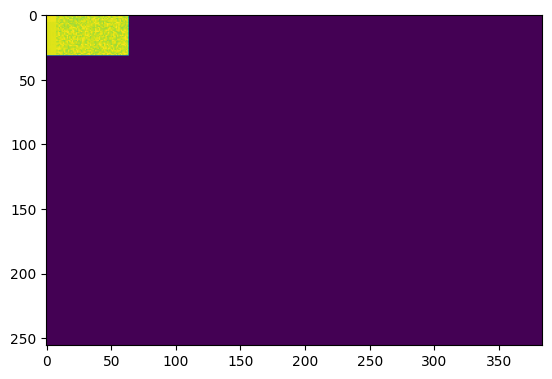

In [5]:
plt.imshow(DN)
plt.savefig('DN.png')

In [6]:
import tiledb

In [7]:
d1 = tiledb.Dim(name="x", domain=(0, 383), tile=64, dtype=np.int32)
d2 = tiledb.Dim(name="y", domain=(0, 255), tile=64, dtype=np.int32)
domain = tiledb.Domain(d1, d2)

In [8]:
attr_pixel = tiledb.Attr(name="pixel", dtype=np.float32)
attr_pixel_modified = tiledb.Attr(name="pixel_modified", dtype=np.float32)
attr_mask = tiledb.Attr(name="mask", dtype=np.float32)

schema = tiledb.ArraySchema(
    domain=domain,
    attrs=[attr_pixel, attr_pixel_modified, attr_mask],
    sparse=False
)

In [11]:
tiledb.DenseArray.create("1CAF.015B9C4A.close", schema)

In [12]:
with tiledb.DenseArray("1CAF.015B9C4A.close", mode="w") as A:
    A[:, :] = {
        "pixel": DN.T.astype(np.int32),                # (384, 256)
        "pixel_modified": Modified_DN.T.astype(np.int32),
        "mask": Mask.T.astype(np.int32),
    }

In [13]:

with tiledb.DenseArray("1CAF.015B9C4A.close", mode="r") as A:
    data = A[:, :]
    pixel_data = data["pixel"]
    pixel_modified_data = data["pixel_modified"]
    mask_data = data["mask"]
    print(pixel_data)
    print(pixel_modified_data)
    print(mask_data)

[[48340. 47905. 48212. ...     0.     0.     0.]
 [47946. 47899. 47934. ...     0.     0.     0.]
 [48337. 47925. 48234. ...     0.     0.     0.]
 ...
 [    0.     0.     0. ...     0.     0.     0.]
 [    0.     0.     0. ...     0.     0.     0.]
 [    0.     0.     0. ...     0.     0.     0.]]
[[48414. 47979. 48286. ...     0.     0.     0.]
 [48020. 47973. 48008. ...     0.     0.     0.]
 [48411. 47999. 48308. ...     0.     0.     0.]
 ...
 [    0.     0.     0. ...     0.     0.     0.]
 [    0.     0.     0. ...     0.     0.     0.]
 [    0.     0.     0. ...     0.     0.     0.]]
[[1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
